#Importing the dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('/kaggle/input/creditcardfraud/creditcard.csv')

# First look
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


0
Class
0    284315
1       492
Name: count, dtype: int64


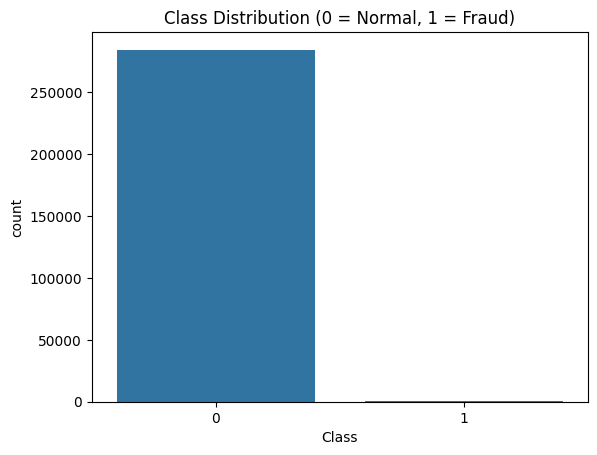

In [ ]:
# Check missing values
print(df.isnull().sum().sum())

# Check class distribution
print(df['Class'].value_counts())

# Visualize imbalance
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0 = Normal, 1 = Fraud)')
plt.show()

Class
0    492
1    492
Name: count, dtype: int64


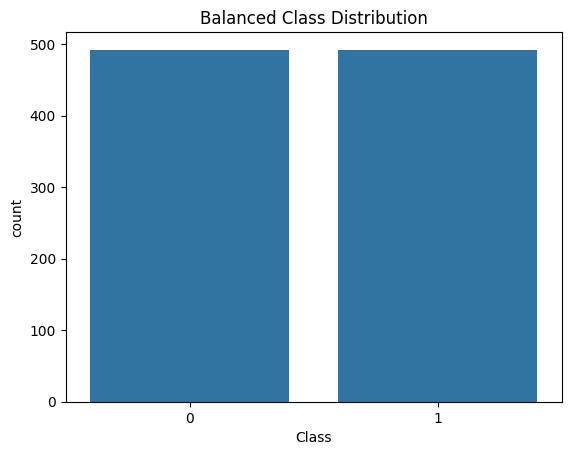

In [ ]:
# Separate fraud and normal transactions
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0].sample(n=492, random_state=42)

# Combine them
balanced_df = pd.concat([fraud, normal])

# Shuffle the dataset
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check new distribution
print(balanced_df['Class'].value_counts())

# Visualize
sns.countplot(x='Class', data=balanced_df)
plt.title('Balanced Class Distribution')
plt.show()

#Feature Scaling

In [ ]:
# Scale Amount and Time columns
scaler = StandardScaler()
balanced_df['Amount'] = scaler.fit_transform(balanced_df[['Amount']])
balanced_df['Time'] = scaler.fit_transform(balanced_df[['Time']])

balanced_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,1.446363,1.984787,-1.937036,0.486613,-1.245536,-2.518536,-0.544524,-1.819244,-0.074875,-0.659777,...,0.174011,0.889289,0.218248,0.492384,-0.584599,-0.135040,0.070319,-0.000205,0.084458,0
1,1.375419,-0.613696,3.698772,-5.534941,5.620486,1.649263,-2.335145,-0.907188,0.706362,-3.747646,...,0.319261,-0.471379,-0.075890,-0.667909,-0.642848,0.070600,0.488410,0.292345,-0.456932,1
2,-0.656191,0.319007,-1.072867,-0.216146,1.494709,-0.627063,-0.761867,0.941687,-0.430272,-0.267431,...,0.332521,-0.022461,-0.537691,0.452072,0.555495,-0.383543,-0.068520,0.106578,1.726673,0
3,1.297532,-6.682832,-2.714268,-5.774530,1.449792,-0.661836,-1.148650,0.849686,0.433427,-1.315646,...,0.220526,1.187013,0.335821,0.215683,0.803110,0.044033,-0.054988,0.082337,0.613485,1
4,-0.054512,-6.713407,3.921104,-9.746678,5.148263,-5.151563,-2.099389,-5.937767,3.578780,-4.684952,...,0.954272,-0.451086,0.127214,-0.339450,0.394096,1.075295,1.649906,-0.394905,0.684137,1


#Train Test Split

In [ ]:
X = balanced_df.drop(columns=['Class'])
y = balanced_df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (787, 30)
Testing size: (197, 30)


#Model Training

In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

#Evaluation

In [ ]:
print("---- Logistic Regression ----")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

print("---- Random Forest ----")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

---- Logistic Regression ----
Accuracy: 0.934010152284264
              precision    recall  f1-score   support

           0       0.90      0.95      0.93        87
           1       0.96      0.92      0.94       110

    accuracy                           0.93       197
   macro avg       0.93      0.94      0.93       197
weighted avg       0.94      0.93      0.93       197

---- Random Forest ----
Accuracy: 0.9238578680203046
              precision    recall  f1-score   support

           0       0.88      0.97      0.92        87
           1       0.97      0.89      0.93       110

    accuracy                           0.92       197
   macro avg       0.92      0.93      0.92       197
weighted avg       0.93      0.92      0.92       197



#Confusion Matrix

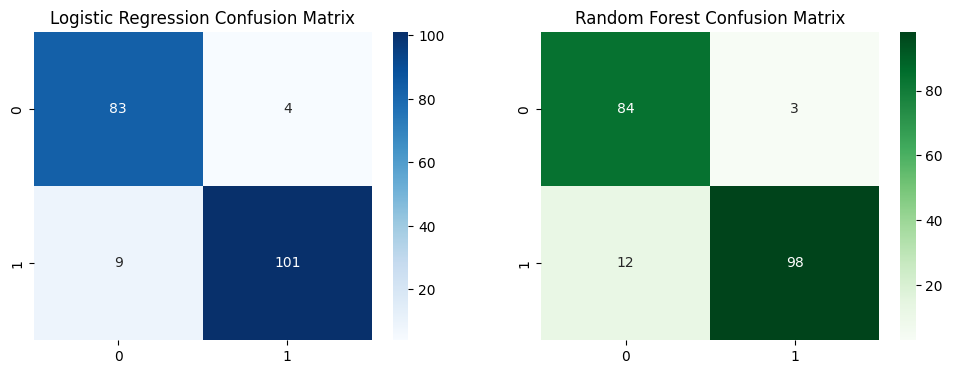

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression Confusion Matrix')

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest Confusion Matrix')

plt.show()

In [ ]:
# Final Summary
print("="*45)
print("  CREDIT CARD FRAUD DETECTION SUMMARY")
print("="*45)
print(f"Total Transactions: 284,807")
print(f"Fraud Cases: 492 (0.17%)")
print(f"Normal Cases: 284,315 (99.83%)")
print("="*45)
print(f"Logistic Regression Accuracy: 93.40%")
print(f"Random Forest Accuracy:       92.38%")
print(f"Best Model: Logistic Regression")
print("="*45)

  CREDIT CARD FRAUD DETECTION SUMMARY
Total Transactions: 284,807
Fraud Cases: 492 (0.17%)
Normal Cases: 284,315 (99.83%)
Logistic Regression Accuracy: 93.40%
Random Forest Accuracy:       92.38%
Best Model: Logistic Regression
